# Problem Set 3
### Matthew McCullough - mlm2393
### Harry Gavras - hg2777
### Daniel Besthof - dfb2131
### Ojas Arun - oa2479

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.api import OLS, add_constant
from statsmodels.tsa.arima.api import ARIMA
from scipy.stats import skew, kurtosis

### 1

$$ r_{t}=\mu +\sigma \varepsilon _{t}+J_{t}\ and \ J_{t}=B_{t}\times \left( \mu _{j}+\sigma _{j}\delta _{t}\right) $$

The expectation is as follows:
$$ \mathbb{E}[r_t] = \mathbb{E}[\mu + \sigma * \epsilon_t] + \mathbb{E}[J_t] = \mu + 0 + p\mu_j$$
$$ E\left[ r_{f}\right] = \mu +p\mu _{j}  $$

The variance is as follows:
$$Var(r_t) = Var(\mu + \sigma * \epsilon_t + J_t) = \sigma^2 Var(\epsilon_t) + Var(J_t) = \sigma^2 + Var(J_t)$$
$$Var(J_t) = Var(B_t * \mu_j) + Var(B_t * \sigma_j * \delta_T)$$
$$\sigma_j^2Var(B_t * \delta_t) = \sigma_j^2\mathbb{E}[(B_t * \delta_t - \mathbb{E}[B_t\delta_t])^2] = \sigma_j^2\mathbb{E}(B_t^2\delta_t^2) = \sigma_j^2p$$
$$Var(B_t * \mu_j) = \mu_j^2 * Var(B_t) = \mu_j^2 * p(1-p)$$
$$ Var\left[ r_{t}\right] =p\mu _{j}^{2}\left( 1-p\right) +p\sigma _{j}^{2}+\sigma ^{2} $$

The skew is derived as follows:
Skew = $$ \dfrac{E\left[ \left( r_{t}-E\left[ r_{t}\right] \right) ^{3}\right] }{\ {var}\left( r_{t}\right) ^{3/2}} $$
$$ r_{t}-E\left[ r_{t}\right]  = \mu +\sigma \varepsilon _{{t}}+J_{t} -\mu -p\mu _{j}= \sigma \varepsilon _{t} + J_{t}-p\mu _{j} $$
$$ \mathbb{E}\!\left[\left(\sigma \varepsilon_t + (J_t - p\mu_j)\right)^3\right] $$

$$ \mathbb{E}\!\left[(\sigma\varepsilon_t + (J_t-p\mu_j))^3\right]
= \mathbb{E}\!\left[(\sigma\varepsilon_t)^3\right] + \mathbb{E}\!\left[(J_t-p\mu_j)^3\right] + 3\,\mathbb{E}\!\left[(\sigma\varepsilon_t)^2\right]\mathbb{E}\!\left[J_t-p\mu_j\right] + 3\,\mathbb{E}\!\left[\sigma\varepsilon_t\right]\mathbb{E}\!\left[(J_t-p\mu_j)^2\right]. $$


 Given that: $$ E\left[ \left( \sigma \varepsilon _{t}\right) \right] =\sigma E\left[ \varepsilon _{t}\right] = 0 $$ and also $$E\left[ J_t\right] =p\mu _{i} E[ J_t\ -p\mu _{j}] =0 $$

$$\mathbb{E}\!\left[(J_t-p\mu_j)^3\right] = \mathbb{E}[J_t^3] -3p\mu_j\,\mathbb{E}[J_t^2] +3(p\mu_j)^2\,\mathbb{E}[J_t] -E[(p\mu_j)^3] $$

$$ = p\left( \mu ^{3}+3\mu _{j}\sigma _{j}^{2}\right) -3p\mu _{j}p\left( \mu _{j}^{2}+\sigma _{j}^{2}\right) +3\left( p\mu _{j}\right) ^{3}-\left( p\mu _{j}\right) ^{3} =
3p\mu _{j}\sigma _{j}^{2}\left( 1-p\right) +p\mu _{j}^{3}\left( 1-3p+2p^{2}\right) $$

So skew is equal to:

 $$=\dfrac{3p\mu _{j}\sigma _{j}^{2}\left( 1-p\right) +p\mu _{j}^{3}\left( 1-3p+2p^{2}\right) } {\left( p\mu _{j}^{2}\left(1-p\right) +p\sigma _{j}^{2}+\sigma ^{2}\right) ^{3/2}} $$

Lastly the Kurtosis is derived as follows:
$$ K\left( r_{t}\right) =E\left[ \dfrac{\left( r_{t}-E\left[ r_{t}\right] \right) ^{4}}{var\left( r_{t}\right) ^{2}}\right] $$

using $$ r_{t}-E\left[ r_{t}\right] = \sigma \varepsilon _{t}+J _{t}-p\mu _{j} $$

$$ E\left[ \left( \sigma \varepsilon _{t}+J_{t}-p\mu _{j}\right) ^{4}\right] = E\left[ \left( \sigma \varepsilon _{t}\right) ^{4}\right] +4E\left[ \left( \sigma {\varepsilon_t}\right) ^{3}\left( J_{t}-p\mu _{t}\right) \right] + 6\,\mathbb{E}\!\left[\left(\sigma\varepsilon_t\right)^2\left(J_t-p\mu_j\right)^2\right] +4\,\mathbb{E}\!\left[\left(\sigma\varepsilon_t\right)\left(J_t-p\mu_j\right)^3\right] +\mathbb{E}\!\left[\left(J_t-p\mu_j\right)^4\right]$$

But we have
1) $$E\left[ \left( \sigma \varepsilon _{t}\right) ^{4}\right]  $$ leads to $$ 3\sigma ^{4}$$ from normal distribution having kurtosis 3.
2) $$ 4E\left[ \left( \sigma {\varepsilon_t}\right) ^{3}\left( J_{t}-p\mu _{t}\right) \right] $$ and $$4E\left[ (\sigma \varepsilon _{t})\left( J_{t}-p\mu _{j}\right) ^{3}\right] \ =0 $$

Thus we get: $$3\sigma ^{4}+6\sigma ^{2}\left[ p\left( \mu _{j}^{2}+\sigma _{j}^{2}\right) -\left( p\mu _{j}\right) ^{2}\right] +p\left( \mu _{j}^{4}+6\mu _{j}^{2}\sigma _{j}^{2}+3\sigma _{j}^{4}\right) -4p^2{\mu_j}\left( \mu ^{3}+3\mu _{j}\sigma _{j}^{2}\right)
 +6p^{3}\mu _{j}^{2}\left( \mu _{j}^{2}+\sigma _{j}^{2}\right) -3\left( p\mu _{j}\right) ^{4}$$

Which simplifies to:
$$ E\left[ \left( r_{t}-E\left[ r_{t}\right] \right) ^{4}\right] =3\sigma ^{4}+6\sigma ^{2}\left[ p\mu _{j}^{2}\left( 1-p\right) +p\sigma _{j}^{2}\right] +
p\left( \mu _{j}^{4}+6\mu_j^{2}\sigma _{j}^{2}+3\sigma _{j}^{4}\right) -4p^{2}\mu _{j}\left( \mu _{j}^{3}+3\mu _{j}\sigma _{j}^{2}\right) +6p^{3}\mu _{j}^{2}\left( \mu _{j}^{2}+\sigma _{j}^{2}\right) -3\left( p\mu _{j }\right) ^{4} $$

So:
$$ \begin{aligned} K(r_t) &= \frac{\mathbb{E}\!\left[\left(r_t-\mathbb{E}[r_t]\right)^4\right]} {\left(p(1-p)\mu_j^2 + p\sigma_j^2 + \sigma^2\right)^2}. \end{aligned} $$

Meaning thus excess kurtosis is:  $$ K\left( r_{t}\right) -3$$


### 2

In the log normal returns model we have:
$$r_t = \mu + \sigma \epsilon_t$$
where $r_t$ are the log returns, and $r_t \sim \mathcal{N}(\mu, \sigma^2)$.

In this case, the skewness of the model is:
$$\frac{E[(r_t-E[r_t])^3]}{\sigma^3} = 0$$

And the kurtosis:
$$\frac{E[(r_t-E[r_t])^4]}{\sigma^4} = 3$$

This means that under the log normal returns model we are expecting normal returns, that is symmetric, and no fat tails to it.

In contrast, when modelling returns we expect a left tail that is more pronounced than the right tail (negative skewness). That is because, many investments with high Sharpe ratios have strongly negatively skewed returns. In addition, returns generally show fat tails, so the kurtosis should be greater than 3. This is because when talking about returns, it is more likely to have an extreme scenario (eg. crashes) than it would be predicted by normal distributions.

Finally, the Bernoulli-normal mixture introduces jumps to the model. This jump means that shocks come periodically, without assuming a continuous and smooth release of information.

For these reasons, the Bernoulli-normal mixture is potentially a better model of returns

In [2]:
def normal_log_returns(T):
    return np.random.normal(loc=0.0004, scale=0.1**2, size=T)


def jump_log_returns(mu, sigma, p, mu_j, sigma_j, T):
    bt = np.random.binomial(n=1, p=p, size=T)
    jt = bt * (mu_j + sigma_j * np.random.normal(loc=0, scale=1, size=T))
    rt = mu + sigma * np.random.normal(loc=0, scale=1, size=T) + jt
    return rt

In [3]:
jump_sim = jump_log_returns(0.0004, 0.01, 0.01, -0.03, 0.04, 2500)
log_ret = normal_log_returns(12_500)
t = np.linspace(1, 12_500/250, num=len(log_ret))
t2 = np.linspace(1, 2500/250, num=len(jump_sim))
real_returns = pd.read_csv('homework3data.csv')
real_returns['year'] = real_returns['year'].astype(str)
real_returns['month'] = real_returns['month'].astype(str)
real_returns['date'] = real_returns['year'] + '-' + real_returns['month']
real_returns['date'] = pd.to_datetime(real_returns['date'], format='%Y-%m')

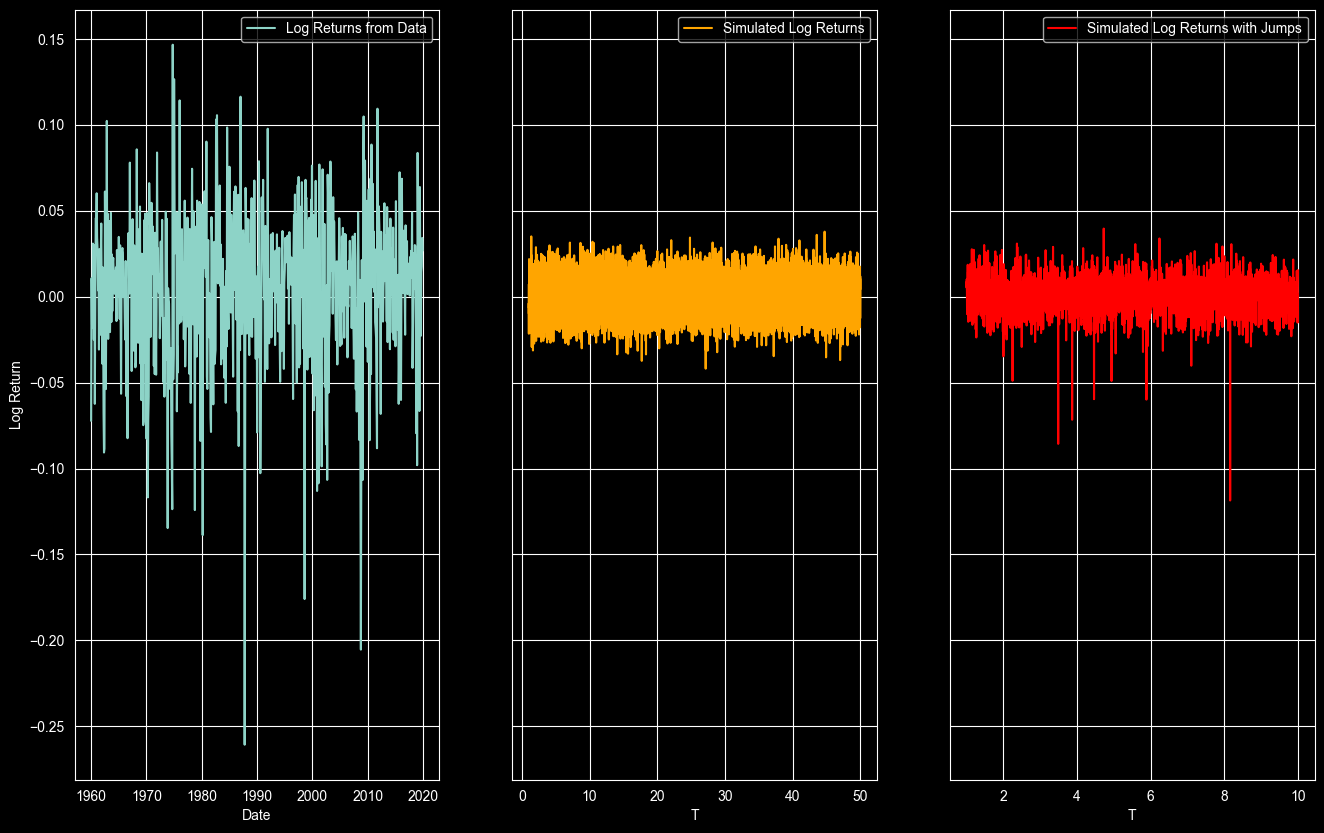

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 10), sharey=True)
sns.lineplot(data=real_returns, x='date', y='log_excess_ret', ax=axes[0], label='Log Returns from Data')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Log Return')
sns.lineplot(x=t, y=log_ret, label='Simulated Log Returns', ax=axes[1], color='orange')
axes[1].set_xlabel('T')
sns.lineplot(x=t2, y=jump_sim, label='Simulated Log Returns with Jumps', ax=axes[2], color='red')
axes[2].set_xlabel('T')
plt.show()

The basic log return model doesn't capture the full dynamics of the real world data. The real world data is much more volatile with periods of extreme volatility and plenty of outlier returns. The basic log return model is missing a jump component to model the crashes seen in the data.
Once we add in the jumps the model looks more like the data but still is not quite the same. We are missing a stochastic volatility component. The real world data exhibits volatility clustering that is not being captured by our Bernoulli-normal mixture model. In order to correct for this, we need our $\sigma$ component to vary through time. With properly estimated parameters, this would allow for the volatility clustering to be captured by our model. Furthermore, we can add in different kinds of jumps. There are some jumps that happen at known times, such as earnings releases, but there are also random jumps. By adding in two different jump components we could more accurately capture the timing of the jumps themselves. With stochastic volatility, pre-determined jumps, and random jumps we would have a much better model of returns.

In [5]:
log_mean = np.mean(log_ret)
log_std = np.std(log_ret)
log_skew = skew(log_ret)
log_kurtosis = kurtosis(log_ret, fisher=False)

jump_mean = np.mean(jump_sim)
jump_std = np.var(jump_sim)
jump_skew = skew(jump_sim)
jump_kurtosis = kurtosis(jump_sim, fisher=False)

pd.DataFrame({'Log Normal': [log_mean, log_std, log_skew, log_kurtosis],
              'Bernoulli': [jump_mean, jump_std, jump_skew, jump_kurtosis]},
             index=['Mean', 'SD', 'Skewness', 'Kurtosis'])

,Log Normal,Bernoulli
Mean,0.000245,0.000323
SD,0.009987,0.000118
Skewness,-0.005416,-1.002759
Kurtosis,2.936570,11.556827


In [6]:
mu = 0.0004
sigma = 0.01
p = 0.01
mu_j = -0.03
sigma_j = 0.04

unconditional_mu = mu + p * mu_j
unconditional_variance = p * mu_j**2 * (1 - p) + p * sigma_j**2 + sigma**2
unconditional_skew = (3 * p * mu_j * sigma_j ** 2 * (1 - p) + p * mu_j**3 * (1- 3*p + 2 * p**2)) / ((p * mu_j**2 * (1-p) + p * sigma_j**2 + sigma**2) ** (3/2))
unconditional_kurtosis = (3 * (sigma ** 4) + 6 * (sigma ** 2) * (p * (mu_j ** 2) * (1 - p) + p * (sigma_j ** 2)) + p * (mu_j ** 4 + 6 * (mu_j ** 2) * (sigma_j ** 2) + 3 * (sigma_j ** 4)) - 4 * (p ** 2) * mu_j * (mu_j ** 3 + 3 * mu_j * sigma_j ** 2) + 6 * (p ** 3) * (mu_j ** 2) * ((mu_j ** 2) + (sigma_j ** 2)) - 3 * (p * mu_j) ** 4) / (unconditional_variance ** 2)
print(f'Unconditional Mean: {unconditional_mu}')
print(f'Unconditional SD: {np.sqrt(unconditional_variance)}')
print(f'Unconditional Skew: {unconditional_skew}')
print(f'Unconditional Kurtosis: {unconditional_kurtosis}')

Unconditional Mean: 0.00010000000000000005
Unconditional SD: 0.011176314240392492
Unconditional Skew: -1.2088206383710394
Unconditional Kurtosis: 13.729041146916632


# 4
Here we want to find the t-stat of the sample mean. In this case, the t-stat is given by:
$$t = \frac{\bar{r}-E[r_t]}{\sqrt{Var(\bar{r})}}$$

where:
$$\bar{r} = \frac{1}{T}\sum_{t=1}^Tr_t = \frac{1}{T}\sum_{t=1}^T(\mu + \sigma \epsilon_t + B_t(\mu_J + \sigma_J \delta_t)) = \mu + \frac{1}{T}\sigma \sum_{t=1}^T\epsilon_t + \frac{1}{T}\sum_{t=1}^T B_t(\mu_J + \sigma_J \delta_t)$$

From Question 1:
$$E[r_t] = \mu + p\mu_J$$

and the variance is given by:

$$Var(\bar{r}) = Var(\frac{1}{T}\sum_{t=1}^Tr_t)= \frac{1}{T^2}Var(\sum_{t=1}^Tr_t)$$
since we are assuming no autocorrelation we get:
$$\frac{1}{T^2}Var(\sum_{t=1}^Tr_t) = \frac{1}{T^2}\sum_{t=1}^TVar(r_t) = \frac{1}{T}Var(r_t)$$

operate under the null hypothesis that the population mean is zero:
$$H_0: E[r_t] = 0$$
This means that:
$$E[r_t] = \mu + p\mu_J = 0 \Rightarrow \mu = -p\mu_J $$

In [7]:
def samples_bernoulli(T):
    rt = jump_log_returns(mu, sigma, p, mu_j, sigma_j, T)
    return rt

def t_statistic(rt):
    T = len(rt)
    mean = np.mean(rt)
    var_mean = np.var(rt)
    std_mean = np.sqrt(var_mean / T)

    return mean / std_mean, mean

def monte_carlo(N, T):
    t_stats = np.zeros(N)
    sample_means = np.zeros(N)

    for nn in range(N):
        rt = samples_bernoulli(T)
        t_stats[nn] = t_statistic(rt)[0]
        sample_means[nn] = t_statistic(rt)[1]

    return t_stats, sample_means


def distribution_plots(year, t_stats, sample_means):

    print(f'Distribution plots for {year/250} years.')

    stand_norm = np.random.normal(0, 1, N)
    sns.histplot(x=t_stats[year], color='blue', label='t-stat')
    sns.histplot(x=stand_norm, color='red', alpha=0.3, label='Standard Normal')
    plt.title('Distribution of t-stat under $H_0$ vs. Standard Normal')
    plt.legend()
    plt.show()

    sns.histplot(x=sample_means[year], color='blue', label='Sample mean')
    plt.title('Distribution of sample means')
    plt.show()

Distribution plots for 0.1 years.


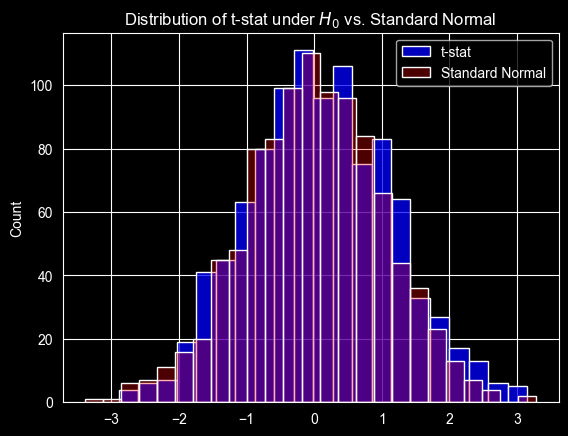

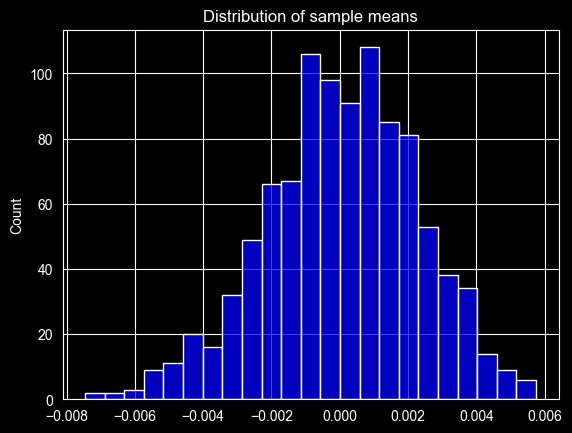

Distribution plots for 0.5 years.


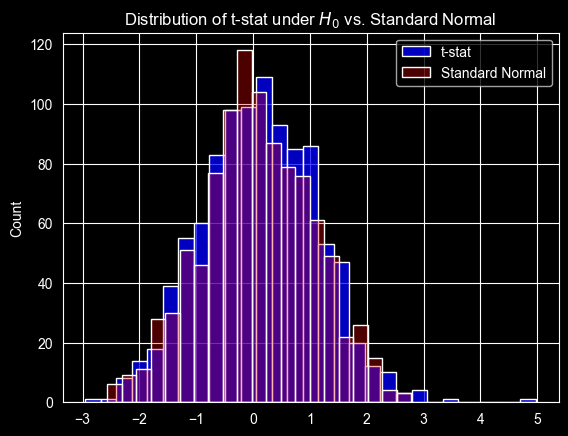

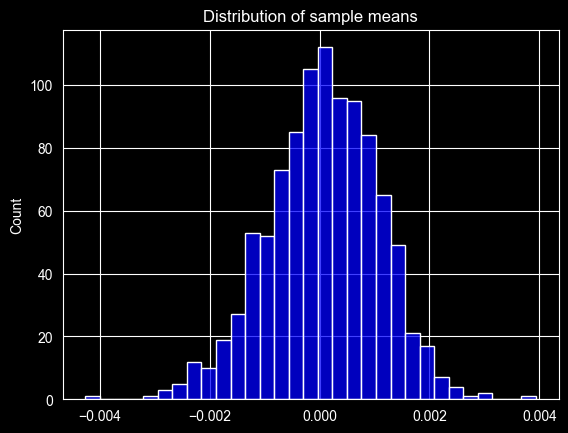

Distribution plots for 1.0 years.


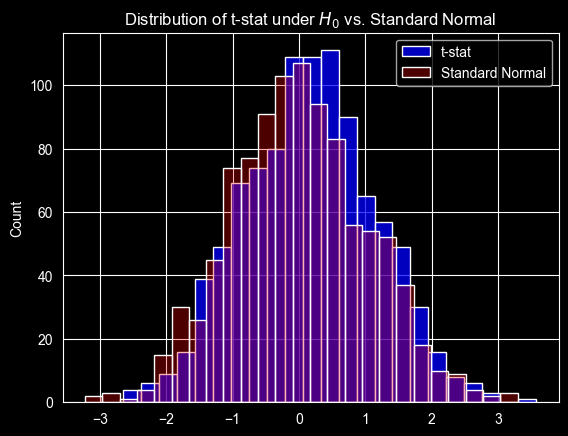

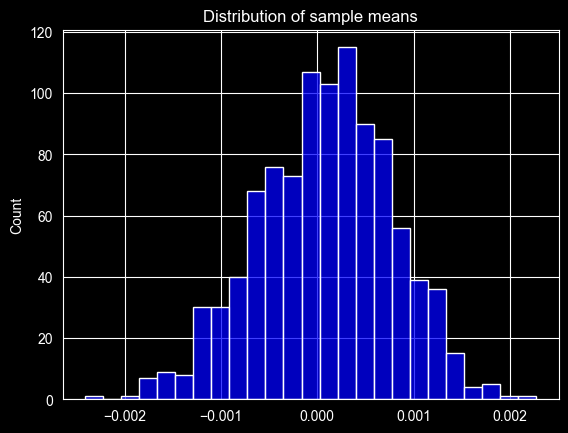

Distribution plots for 2.0 years.


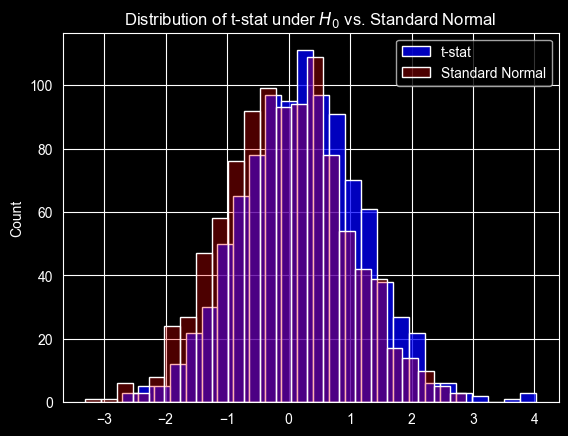

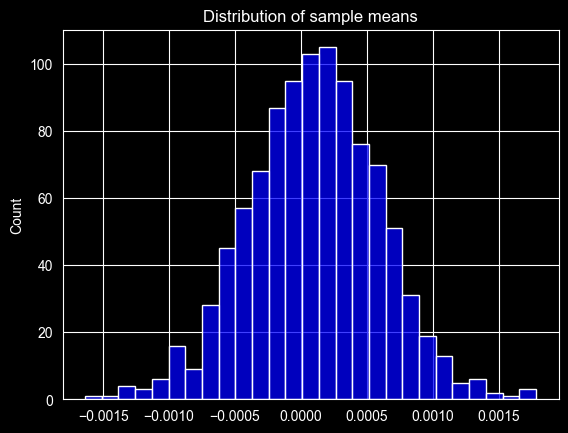

Distribution plots for 4.0 years.


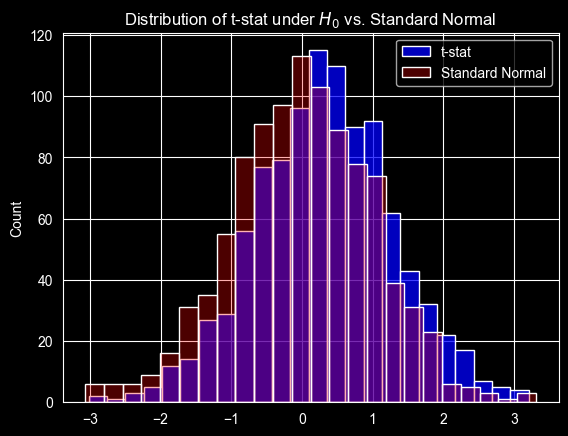

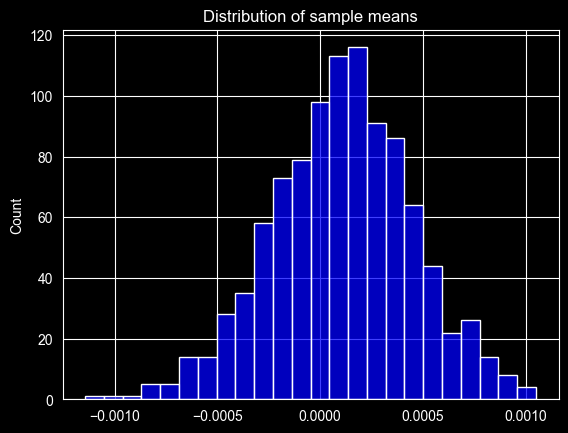

In [8]:
N = 1000
T = [25, 125, 250, 500, 1000]
t_stats_dict = dict()
sample_mean_dict = dict()

for year in T:
    t_stats, sample_mean = monte_carlo(N, year)
    t_stats_dict[year] = t_stats
    sample_mean_dict[year] = sample_mean
    distribution_plots(year, t_stats_dict, sample_mean_dict)

In [9]:
for year in T:
    print(f'The t-stat and sample mean moments for {year/250} years:')
    df = pd.DataFrame({'t-stat': [np.mean(t_stats_dict[year]), np.std(t_stats_dict[year]), skew(t_stats_dict[year]), kurtosis(t_stats_dict[year])],
                        'Sample Mean': [np.mean(sample_mean_dict[year]), np.std(sample_mean_dict[year]), skew(sample_mean_dict[year]), kurtosis(sample_mean_dict[year])]},
                        index = ['Mean', 'STD','Skewness', 'Kurtosis'])
    print(df)

The t-stat and sample mean moments for 0.1 years:
            t-stat  Sample Mean
Mean      0.088342     0.000054
STD       1.063443     0.002240
Skewness  0.093210    -0.237627
Kurtosis -0.169772    -0.009512
The t-stat and sample mean moments for 0.5 years:
            t-stat  Sample Mean
Mean      0.118382     0.000069
STD       1.011887     0.001002
Skewness  0.141423    -0.203979
Kurtosis  0.195041     0.368226
The t-stat and sample mean moments for 1.0 years:
            t-stat  Sample Mean
Mean      0.157885     0.000081
STD       0.995191     0.000699
Skewness  0.046423    -0.168312
Kurtosis -0.190226    -0.101418
The t-stat and sample mean moments for 2.0 years:
            t-stat  Sample Mean
Mean      0.230028     0.000102
STD       0.998041     0.000496
Skewness  0.150921    -0.040222
Kurtosis  0.323428     0.325370
The t-stat and sample mean moments for 4.0 years:
            t-stat  Sample Mean
Mean      0.316420     0.000105
STD       0.980809     0.000343
Skewness -0.03

The Sample Means and t-stats which we have shown above for the 1 year simluation look normally distributed & centered around 0. The overlap between the red (standard normal) and t-stat (blue) is very high. Visually we cannot see a clear difference in tails. The sample mean is in fact 0.000012 leading to a t-stat of the mean being 0 of 0.05 meaning we do not reject it. However, once we start looking at different time frames we can see a trend. Starting with 0.1 years timeframe we see a right tail for the t-stat which also still exists for the 0.5 year time frame. Once we get past 1 year and to 2 & 5 years that right tail for t-stat disappears and the data starts looking closer to a normal distribution. Despite the introduction of jumps, the distribution of the t-statistic based on the (no-autocorrelation) White standard error is close to N(0,1) and seems to become more normal as T increases and skewness and excess kurtosis decline toward zero. This can be argued via the central limit theorem which means the more observations we use the closer we get to a normal distribution. As a matter of fact once we look closer at the results table (t-stat & Sample Mean) across time periods the Sample Mean converges to 0 while the standard deviation also decreases. Taking 0.1 years we have mean: 0.000057 & SD: 0.002174 which as we increase the time fram moves to 0.000001 & 0.00335 respectively. Again we can use the argument of the central limit theorem here to explain this phenomenon. Specifically the as T increases the sample mean becomes smaller at a rate of:

$$ \frac{1}{\sqrt{250 * T}}$$
Similarly the same argument can be made for skewness and kurtosis which exist 'mildly' in the early time frames (hence the tails) but reduce over time.

# Question 2
### 1

In [10]:
real_returns['rt+1'] = real_returns['log_excess_ret'].shift(-1) * 12
real_returns.dropna(inplace=True)
X = real_returns['div_yld']
X = add_constant(X)
X.columns = ['alpha', 'dividend_yield']
y = real_returns['rt+1']

In [11]:
reg = OLS(y, X).fit(cov_type='HC3')
reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   rt+1   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.243
Date:                Wed, 18 Feb 2026   Prob (F-statistic):              0.265
Time:                        21:11:04   Log-Likelihood:                -558.74
No. Observations:                 719   AIC:                             1121.
Df Residuals:                     717   BIC:                             1131.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
alpha             -0.0211      0.065     -0.323      0.747      -0.149       0.107
dividend_yield     2.5456      2.283      1.115      0.265      -1.929       7.020
==============================================================================
Omnibus:                      119.913   Durbin-Watson:                   1.830
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              323.841
Skew:                          -0.845   Prob(JB):                     4.77e-71
Kurtosis:                       5.820   Cond. No.                         101.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

In [12]:
print(reg.t_test('dividend_yield = 0'))

                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0             2.5456      2.283      1.115      0.265      -1.929       7.020


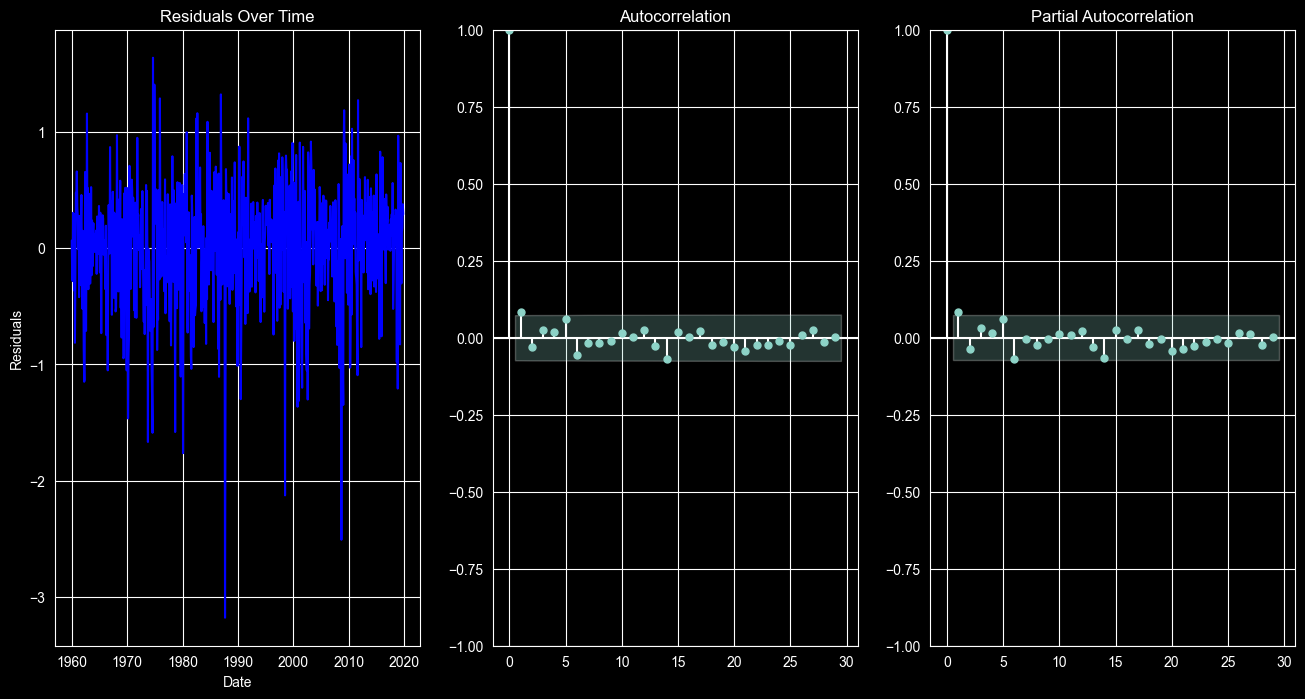

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 8))
sns.lineplot(x=real_returns['date'], y=reg.resid, ax=axes[0], color='blue')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals Over Time')
acf = plot_acf(x=reg.resid, ax=axes[1])
pacf = plot_pacf(x=reg.resid, ax=axes[2])
plt.show()

### 2



We know that for $\hat{\beta}_{OLS}$ to be consistent, then $\hat{\beta}_{OLS} \overset{p}{\to} \beta$. Here, we have ran the regression $$r_{t+1} = \alpha + \beta dy_t + \epsilon_{t+1}$$

The OLS estimator $\hat{\beta}_{OLS}$ minimizes the in-sample mean squared error:
$$\sum_i (Y_i - X_i \beta)^2 = (Y_i - X_i \beta)' (Y_i - X_i \beta)$$
where in our case $Y_i = r_{t+1}$ and $X_i = dy_t$. 

When including an intercept in the OLS then: 
$$\hat{\beta}_{OLS} = \frac{\sum_t (dy_t - \bar{dy}) (r_{t+1} - \bar{r})}{\sum_t (dy_t - \bar{dy})^2}$$

This means that we have:
$$\hat{\beta}_{OLS} = \frac{\sum_t (dy_t - \bar{dy}) ((\alpha + \beta dy_t + \epsilon_{t+1}) - (\alpha + \beta \bar{dy} + \bar{\epsilon}))}{\sum_t (dy_t - \bar{dy})^2}$$
$$= \frac{\sum_t (dy_t - \bar{dy}) ((\beta (dy_t - \bar{dy}) + (\epsilon_{t+1}- \bar{\epsilon})))}{\sum_t (dy_t - \bar{dy})^2}$$
$$\hat{\beta}_{OLS} = \beta + \frac{\sum_t (dy_t - \bar{dy}) (\epsilon_{t+1}- \bar{\epsilon})}{\sum_t (dy_t - \bar{dy})^2} = \beta + \frac{\frac{1}{N}\sum_t (dy_t - \bar{dy}) (\epsilon_{t+1}- \bar{\epsilon})}{\frac{1}{N}\sum_t (dy_t - \bar{dy})^2}$$

Where we have by the law of large numbers: $\frac{1}{N}\sum_t (dy_t - \bar{dy}) (\epsilon_{t+1}- \bar{\epsilon}) \overset{p}{\to} Cov(dy, \epsilon)$, and $\frac{1}{N}\sum_t (dy_t - \bar{dy})^2 \overset{p}{\to} Var[dy]$

Thus:
$$plim \hat{\beta}_{OLS} = \beta + \frac{Cov(dy, \epsilon)}{Var[dy]}$$

So, for $\hat{\beta}_{OLS}$ to be consistent we need $\frac{Cov(dy, \epsilon)}{Var[dy]} = 0$. 

In [14]:
frac = real_returns['div_yld'].cov(reg.resid) / real_returns['div_yld'].var()
print(f'The covariance of divident yield and the residual over the variance of the divident yield is {frac}')

The covariance of divident yield and the residual over the variance of the divident yield is -1.2742828567688346e-15


As we can see $\frac{Cov(dy, \epsilon)}{Var[dy]} = 0$, so $$plim \hat{\beta}_{OLS} = \beta$$ and the estimator is consistent.

### 3

#### Code explanation

The dataset starts with January 1960. We want the dividend yield at this time to predict the returns for the 12 months that follow, ie February 1960 - January 1961.
For this date we will use the div_yld of the same index. For the $r_{t+12,12}$ value we will shift the log_excess_returns column by 11 days, to capture the next twelve months.

In [15]:
k = 11
real_returns['rt12_12'] = real_returns.log_excess_ret.rolling(window = 12).sum().shift(-11)
real_returns.dropna(inplace=True)

In [16]:
X = add_constant(real_returns['div_yld'])
X.columns = ['alpha', 'dividend_yield']
y = real_returns['rt12_12']

In [17]:
overlap_reg = OLS(y, X).fit(cov_type='HC3')
overlap_reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                rt12_12   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     14.35
Date:                Wed, 18 Feb 2026   Prob (F-statistic):           0.000164
Time:                        21:11:04   Log-Likelihood:                 293.87
No. Observations:                 708   AIC:                            -583.7
Df Residuals:                     706   BIC:                            -574.6
Df Model:                           1                                         
Covariance Type:                  HC3                                         
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
alpha             -0.0141      0.019     -0.755      0.450      -0.051       0.023
dividend_yield     2.2528      0.595      3.789      0.000       1.087       3.418
==============================================================================
Omnibus:                      103.291   Durbin-Watson:                   0.148
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              157.258
Skew:                          -0.976   Prob(JB):                     7.11e-35
Kurtosis:                       4.235   Cond. No.                         101.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

In [18]:
print(overlap_reg.t_test('dividend_yield = 0'))
print(f'R-Squared: {overlap_reg.rsquared:.4f}')

                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0             2.2528      0.595      3.789      0.000       1.087       3.418
R-Squared: 0.0193


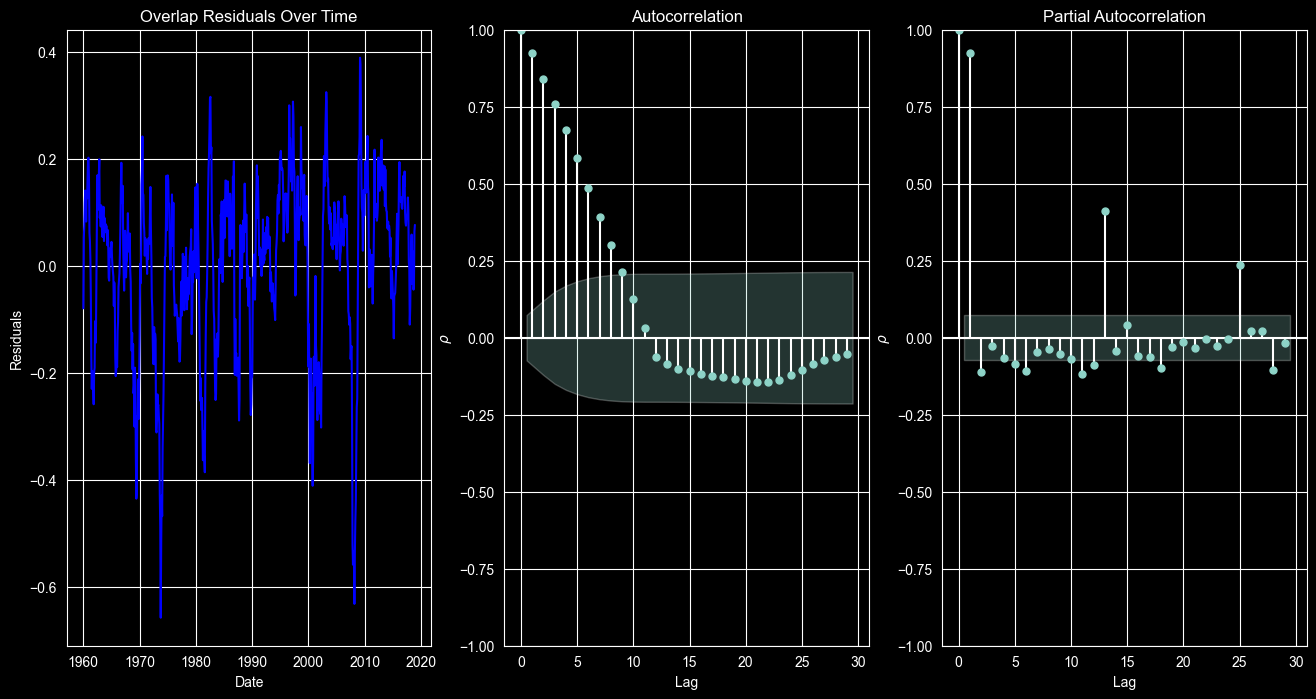

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 8))
sns.lineplot(x=real_returns['date'], y=overlap_reg.resid, ax=axes[0], color='blue')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Overlap Residuals Over Time')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('$\\rho$')
axes[2].set_xlabel('Lag')
axes[2].set_ylabel('$\\rho$')
acf = plot_acf(x=overlap_reg.resid, ax=axes[1])
pacf = plot_pacf(x=overlap_reg.resid, ax=axes[2])
plt.show()

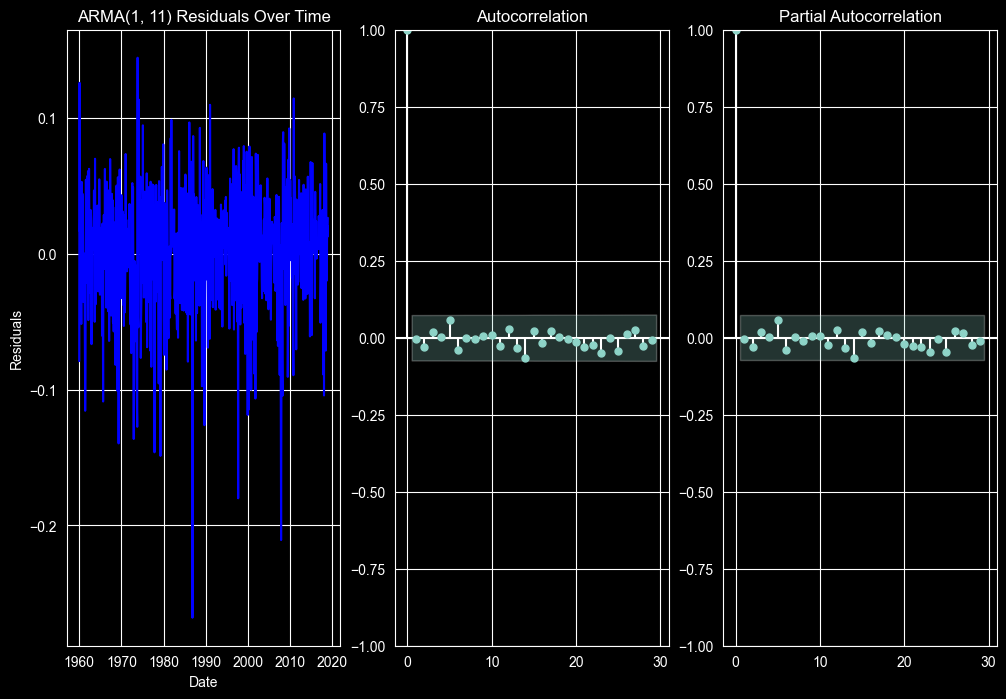

In [20]:
arima = ARIMA(overlap_reg.resid, order=(1, 0, 11), trend='n').fit(method='innovations_mle')
fig, axes = plt.subplots(1, 3, figsize=(12, 8))
sns.lineplot(x=real_returns['date'], y=arima.resid, ax=axes[0], color='blue')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Residuals')
axes[0].set_title('ARMA(1, 11) Residuals Over Time')
acf = plot_acf(x=arima.resid, ax=axes[1])
pacf = plot_pacf(x=arima.resid, ax=axes[2])
plt.show()

In [21]:
arima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  708
Model:                ARIMA(1, 0, 11)   Log Likelihood                1177.346
Date:                Wed, 18 Feb 2026   AIC                          -2328.692
Time:                        21:11:04   BIC                          -2269.380
Sample:                             0   HQIC                         -2305.777
                                - 708                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0764      0.034      2.252      0.024       0.010       0.143
ma.L1          0.9533      0.046     20.542      0.000       0.862       1.044
ma.L2          0.9422      0.020     46.122      0.000       0.902       0.982
ma.L3          0.9614      0.055     17.521      0.000       0.854       1.069
ma.L4          0.9678      0.034     28.581      0.000       0.901       1.034
ma.L5          0.9741      0.057     16.942      0.000       0.861       1.087
ma.L6          0.9609      0.028     34.892      0.000       0.907       1.015
ma.L7          0.9466      0.051     18.534      0.000       0.847       1.047
ma.L8          0.9276      0.026     35.928      0.000       0.877       0.978
ma.L9          0.9275      0.057     16.373      0.000       0.816       1.039
ma.L10         0.9237      0.037     24.635      0.000       0.850       0.997
ma.L11         0.9567      0.052     18.324      0.000       0.854       1.059
sigma2         0.0020      0.000     17.425      0.000       0.002       0.002
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):               287.53
Prob(Q):                              0.99   Prob(JB):                         0.00
Heteroskedasticity (H):               1.01   Skew:                            -0.82
Prob(H) (two-sided):                  0.91   Kurtosis:                         5.66
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Looking at the residuals, PACF, and ACF it looks like the residuals follow an ARMA process. We can confirm this by fitting an ARMA(1, 11) and looking at the residuals of that to see if we can capture the dynamics of the process. The use of overlapping 12-month returns results in serial correlation in the regression errors, since consecutive observations share 12 months of underlying returns. K-period overlapping returns imply that the regression error follows an MA(k-1) process. Hence, the residuals exhibit an MA(11) process. The sample ACF shows slow decay, while the PACF shows a dominant spike at lag one, clearly indicating an AR(1) component as well. Hence, these patterns suggest an ARMA(1,11) process. Also, there is potentially a seasonal AR component at the later lags. However, after fitting an ARMA(1, 11) to the residuals we can see that the residuals of the ARMA(1, 11) are white noise. This indicates that we were able to capture all the signal in the model with our chosen parameters. The autocorrelation in the residuals for our regression can be accounted for in our standard errors by using HAC standard errors. To see how the errors change, we'll run another regression.

In [22]:
overlap_reg2 = OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 11})
overlap_reg2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                rt12_12   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     1.971
Date:                Wed, 18 Feb 2026   Prob (F-statistic):              0.161
Time:                        21:11:04   Log-Likelihood:                 293.87
No. Observations:                 708   AIC:                            -583.7
Df Residuals:                     706   BIC:                            -574.6
Df Model:                           1                                         
Covariance Type:                  HAC                                         
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
alpha             -0.0141      0.053     -0.267      0.790      -0.118       0.090
dividend_yield     2.2528      1.605      1.404      0.160      -0.892       5.398
==============================================================================
Omnibus:                      103.291   Durbin-Watson:                   0.148
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              157.258
Skew:                          -0.976   Prob(JB):                     7.11e-35
Kurtosis:                       4.235   Cond. No.                         101.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 11 lags and without small sample correction
"""

In [23]:
print(overlap_reg2.t_test('dividend_yield = 0'))
print(f'R-Squared: {overlap_reg2.rsquared:.4f}')

                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0             2.2528      1.605      1.404      0.160      -0.892       5.398
R-Squared: 0.0193


Once we switch to HAC errors, we do not have sufficient evidence to reject the null hypothesis, thus the dividend yield is insignificant. Overall, the HAC error bands were much larger to account for the estimation uncertainty that comes with autocorrelated errors.